# Phase 5 — ARIMA Model
**Project:** Forecasting the Recovery of Global Economies from Shocks through Time Series Modeling

**Goal:** Fit ARIMA model per country on training data (1990–2018), forecast the test period (2019–2024), and compare performance against XGBoost.

**Model:**
- **ARIMA(1,1,1)** — AutoRegressive Integrated Moving Average (handles non-stationarity via differencing)

**Metrics:** MAE, RMSE, MAPE, MASE, Directional Accuracy (DA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.float_format", "{:.4f}".format)
OUTPUT = r"..\output"
print("Libraries OK")
print("statsmodels version:", __import__("statsmodels").__version__)

Libraries OK
statsmodels version: 0.14.4


## 1. Load & Prepare Data

In [2]:
# Use the clean model_training_dataset — 14 columns, zero leakage
# Only gdp_per_capita is needed here (per-country time series)
df = pd.read_csv(os.path.join(OUTPUT, "model_training_dataset.csv"))
df = df.sort_values(["country_code", "year"]).reset_index(drop=True)
df = df.dropna(subset=["gdp_per_capita"])

print("Shape:", df.shape)
print("Years:", df["year"].min(), "-", df["year"].max())
print("Countries:", df["country_code"].nunique())

TRAIN_END  = 2015
VAL_START  = 2016
VAL_END    = 2018
TEST_START = 2019
VAL_YEARS  = list(range(VAL_START, VAL_END + 1))
TEST_YEARS = list(range(TEST_START, 2025))
print("Validation years:", VAL_YEARS)
print("Test years:", TEST_YEARS)

Shape: (7240, 14)
Years: 1990 - 2024
Countries: 212
Validation years: [2016, 2017, 2018]
Test years: [2019, 2020, 2021, 2022, 2023, 2024]


## 2. Stationarity Check — ADF Test (Sample Countries)

In [3]:
sample_adf = ['USA', 'GBR', 'CHN', 'IND', 'DEU']
adf_results = []
for c in sample_adf:
    series = df[df['country_code'] == c].set_index('year')['gdp_per_capita'].dropna()
    r = adfuller(series)
    status = 'Stationary' if r[1] < 0.05 else 'Non-stationary (d=1)'
    adf_results.append({'Country': c, 'ADF Stat': round(r[0], 4), 'p-value': round(r[1], 4), 'Status': status})

adf_df = pd.DataFrame(adf_results)
print('ADF Test Results (H0: series has unit root):')
print(adf_df.to_string(index=False))
print()
print('=> Most GDP series are non-stationary => ARIMA uses d=1 (first difference)')

ADF Test Results (H0: series has unit root):
Country  ADF Stat  p-value               Status
    USA    0.3787   0.9807 Non-stationary (d=1)
    GBR   -1.5572   0.5051 Non-stationary (d=1)
    CHN    0.4938   0.9847 Non-stationary (d=1)
    IND    3.3912   1.0000 Non-stationary (d=1)
    DEU   -0.9255   0.7795 Non-stationary (d=1)

=> Most GDP series are non-stationary => ARIMA uses d=1 (first difference)


## 3. ARIMA(1,1,1) Model — Per Country

Strategy:
- **ARIMA(1,1,1)**: AR order p=1, Integration d=1 (handles non-stationarity), MA order q=1
- Fit on each country's training series (1990–2018)
- Forecast 6 steps ahead (2019–2024)
- Fallback to naive last-value repeat if convergence fails

In [4]:
def fit_arima_forecast(series_train, n_forecast, order=(1, 1, 1)):
    """Fit ARIMA and return n_forecast future values plus success flag."""
    try:
        # Reset to RangeIndex so statsmodels forecast indexing works correctly
        series = series_train.reset_index(drop=True)
        # enforce_stationarity/invertibility=False avoids MLE constraint violations
        # that cause non-convergence on short or near-unit-root GDP series
        model = ARIMA(series, order=order,
                      enforce_stationarity=False,
                      enforce_invertibility=False)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                # innovations_mle: faster & more stable than default statespace MLE
                fit = model.fit(method='innovations_mle')
            except Exception:
                # hannan_rissanen: non-iterative, always converges
                fit = model.fit(method='hannan_rissanen')
        return np.array(fit.forecast(steps=n_forecast)), True
    except Exception:
        last = series_train.iloc[-1]
        return np.array([last] * n_forecast), False


def run_arima_all_countries(df, train_end=2018, test_years=None):
    """Fit ARIMA per country on train split; collect test predictions."""
    if test_years is None:
        test_years = list(range(2019, 2025))

    records, success, fail = [], 0, 0

    for country, grp in df.groupby('country_code'):
        grp = grp.sort_values('year')
        train_series = grp[grp['year'] <= train_end].set_index('year')['gdp_per_capita'].dropna()
        actual_test  = grp[grp['year'].isin(test_years)][['year', 'gdp_per_capita']]

        if len(train_series) < 5 or actual_test.empty:
            continue

        forecasts, ok = fit_arima_forecast(train_series, len(test_years))
        success += int(ok); fail += int(not ok)

        for i, yr in enumerate(test_years):
            row = actual_test[actual_test['year'] == yr]
            if row.empty:
                continue
            records.append({
                'country_code': country,
                'year': yr,
                'actual': row['gdp_per_capita'].values[0],
                'arima_pred': forecasts[i],
            })

    print(f'ARIMA --- OK: {success}, fallbacks: {fail}')
    return pd.DataFrame(records)


In [5]:
print('Fitting ARIMA(1,1,1) for validation years...')
arima_val_preds = run_arima_all_countries(df, train_end=TRAIN_END, test_years=VAL_YEARS)
print('ARIMA validation predictions shape:', arima_val_preds.shape)

print('\nRetraining ARIMA through validation period for final test years...')
arima_preds = run_arima_all_countries(df, train_end=VAL_END, test_years=TEST_YEARS)
print('ARIMA test predictions shape:', arima_preds.shape)
arima_preds.head(10)

Fitting ARIMA(1,1,1) for validation years...
ARIMA --- OK: 210, fallbacks: 1
ARIMA validation predictions shape: (633, 4)

Retraining ARIMA through validation period for final test years...
ARIMA --- OK: 211, fallbacks: 1
ARIMA test predictions shape: (1259, 4)


,country_code,year,actual,arima_pred
0,ABW,2019,39652.6330,38732.8898
1,ABW,2020,30347.6370,39278.8261
2,ABW,2021,35104.7850,38732.8937
3,ABW,2022,38979.8360,39278.8222
4,ABW,2023,41964.7700,38732.8976
5,ABW,2024,44558.9300,39278.8183
6,AFG,2019,2927.2450,2903.9419
7,AFG,2020,2769.6858,2905.2969
8,AFG,2021,2144.1665,2906.4816
9,AFG,2022,1981.7102,2907.5174


## 4. ARIMA Metrics

In [6]:
# ── Shared metric helpers ────────────────────────────────────────────────────
def compute_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def compute_da(y_true, y_pred, y_lag):
    actual_dir = np.sign(np.array(y_true) - np.array(y_lag))
    pred_dir   = np.sign(np.array(y_pred) - np.array(y_lag))
    return np.mean(actual_dir == pred_dir) * 100

# ── MASE denominator: Naive test MAE from Phase 4 ────────────────────────────
# Using the same denominator as Phase 4 ensures MASE is comparable across models
metrics_so_far = pd.read_csv(os.path.join(OUTPUT, "model_metrics.csv"), index_col=0)
naive_mae = float(metrics_so_far.loc["Naive", "MAE"])
print(f"Naive MAE (from model_metrics.csv, test 2019-2024): {naive_mae:,.2f}")

# Build lag column (previous year actual GDP) using a fast lookup dict
lag_map = df.set_index(["country_code", "year"])["gdp_per_capita"].to_dict()

def evaluate_forecast(pred_df, pred_col, label):
    pred_df = pred_df.sort_values(["country_code", "year"]).reset_index(drop=True)
    pred_df["lag_gdp"] = pred_df.apply(
        lambda r: lag_map.get((r["country_code"], r["year"] - 1), r["actual"]), axis=1)
    valid = pred_df[pred_col].notna() & pred_df["actual"].notna()
    yt = pred_df.loc[valid, "actual"]
    yp = pred_df.loc[valid, pred_col]
    yl = pred_df.loc[valid, "lag_gdp"]
    metrics = {
        "MAE":  mean_absolute_error(yt, yp),
        "RMSE": np.sqrt(mean_squared_error(yt, yp)),
        "MAPE": compute_mape(yt, yp),
        "MASE": mean_absolute_error(yt, yp) / naive_mae,
        "DA":   compute_da(yt, yp, yl),
    }
    print(f"\n--- {label} Metrics ---")
    for k, v in metrics.items():
        unit = "%" if k in ("MAPE", "DA") else ""
        print(f"  {k}: {v:.2f}{unit}")
    return pred_df, metrics

arima_val_preds, arima_val_metrics = evaluate_forecast(arima_val_preds, "arima_pred", "ARIMA Validation")
arima_preds, arima_metrics = evaluate_forecast(arima_preds, "arima_pred", "ARIMA Final Test")

Naive MAE (from model_metrics.csv, test 2019-2024): 1,259.16

--- ARIMA Validation Metrics ---
  MAE: 1269.68
  RMSE: 4421.48
  MAPE: 4.32%
  MASE: 1.01
  DA: 54.19%

--- ARIMA Final Test Metrics ---
  MAE: 1945.01
  RMSE: 5883.84
  MAPE: 7.61%
  MASE: 1.54
  DA: 59.81%


## 6. Model Comparison — ARIMA vs XGBoost

In [7]:
try:
    xgb_metrics_df = pd.read_csv(r'..\output\model_metrics.csv', index_col=0)
    xgb_metrics = xgb_metrics_df.loc['XGBoost'].to_dict()
    print('XGBoost metrics loaded from file')
except Exception:
    xgb_metrics = {'MAE': None, 'RMSE': None, 'MAPE': None, 'MASE': None, 'DA': None}
    print('XGBoost metrics not found — run Phase 4 first')

comparison = pd.DataFrame({
    'XGBoost':  xgb_metrics,
    'ARIMA':    arima_metrics,
}).T
comparison.index.name = 'Model'
print('\\n=== Model Comparison (Test Set 2019-2024) ===')
print(comparison.round(4))

XGBoost metrics loaded from file
\n=== Model Comparison (Test Set 2019-2024) ===
              MAE      RMSE   MAPE   MASE      DA
Model                                            
XGBoost 1254.2252 3602.8139 4.8556 0.9961 59.2635
ARIMA   1945.0129 5883.8395 7.6090 1.5447 59.8094


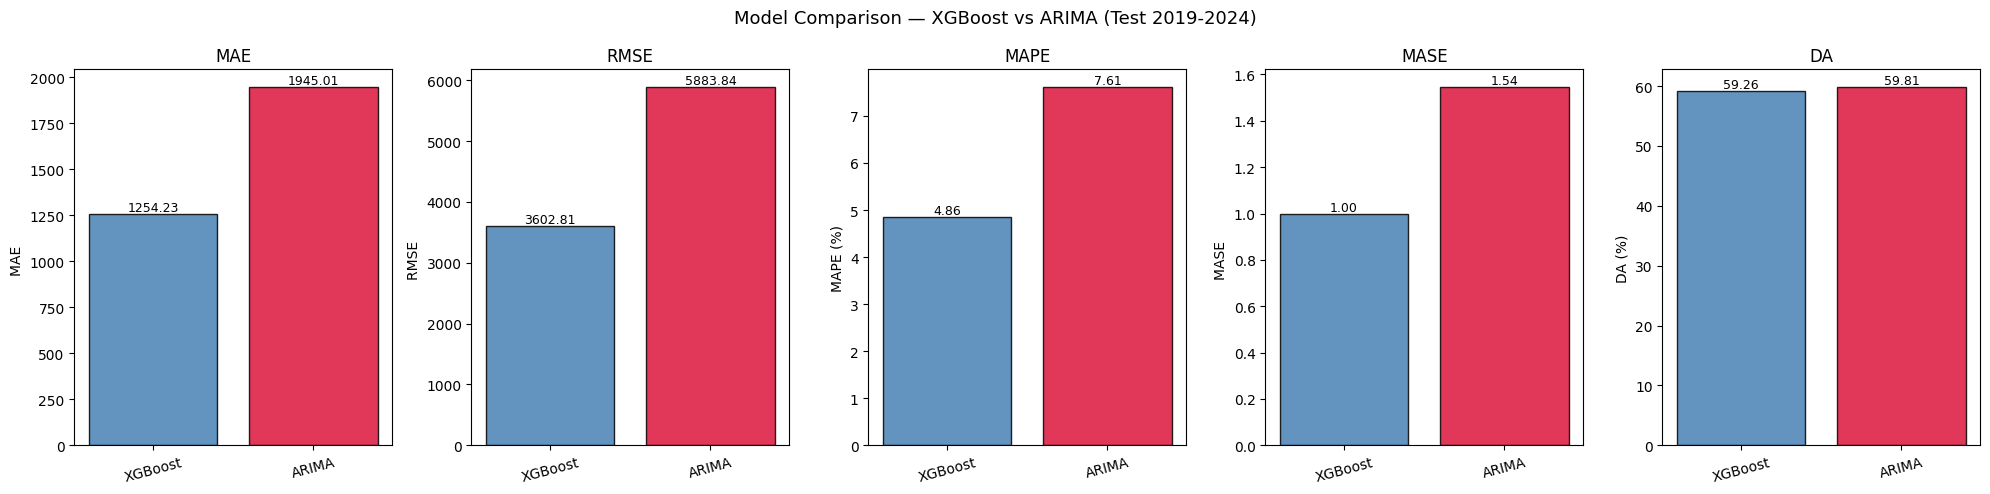

In [8]:
models  = ['XGBoost', 'ARIMA']
metrics = ['MAE', 'RMSE', 'MAPE', 'MASE', 'DA']
colors  = ['steelblue', 'crimson']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, metric in zip(axes, metrics):
    vals = []
    for m in models:
        try:
            v = float(comparison.loc[m, metric])
        except Exception:
            v = 0.0
        vals.append(v)
    bars = ax.bar(models, vals, color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(f'{metric} {"(%)" if metric in ("MAPE","DA") else ""}')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison — XGBoost vs ARIMA (Test 2019-2024)', fontsize=13)
plt.tight_layout()
plt.savefig(r'..\output\phase5_model_comparison.png', dpi=150)
plt.show()

## 7. Country Trajectory Plots — ARIMA vs XGBoost

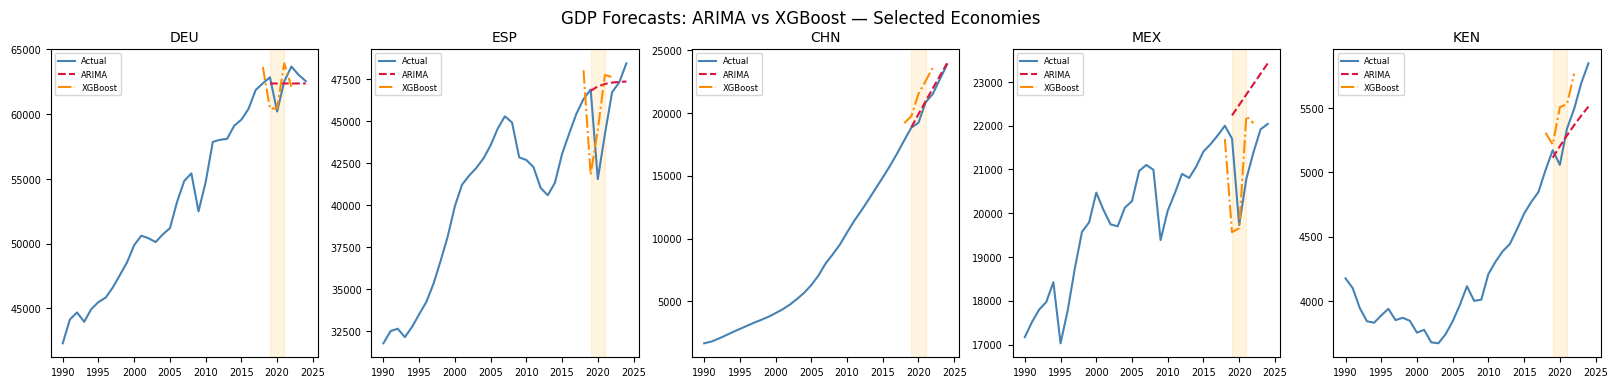

In [9]:
# Merge predictions for plotting
combined = arima_preds[['country_code', 'year', 'actual', 'arima_pred']].copy()

try:
    xgb_preds = pd.read_csv(r'..\output\xgb_test_predictions.csv')
    combined = combined.merge(
        xgb_preds[['country_code', 'year', 'y_pred']].rename(columns={'y_pred': 'xgb_pred'}),
        on=['country_code', 'year'], how='left')
except Exception:
    combined['xgb_pred'] = np.nan

# Selected 5 countries representing different recovery profiles:
# Germany: developed fast recovery | Spain: developed slow recovery
# China: emerging super-fast | Mexico: emerging slower | Kenya: low-income
SAMPLE_COUNTRIES = ['DEU', 'ESP', 'CHN', 'MEX', 'KEN']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes = axes.flatten()

for ax, country in zip(axes, SAMPLE_COUNTRIES):
    hist = df[df['country_code'] == country].sort_values('year')[['year', 'gdp_per_capita']]
    pred = combined[combined['country_code'] == country].sort_values('year')
    if hist.empty or pred.empty:
        ax.set_title(f'{country} - no data'); continue

    ax.plot(hist['year'], hist['gdp_per_capita'],  color='steelblue', lw=1.5, label='Actual')
    ax.plot(pred['year'], pred['arima_pred'],       color='crimson',   lw=1.5, ls='--',  label='ARIMA')
    if 'xgb_pred' in pred.columns and pred['xgb_pred'].notna().any():
        ax.plot(pred['year'] - 1, pred['xgb_pred'],color='darkorange', lw=1.5, ls='-.', label='XGBoost')
    ax.axvspan(2019, 2021, alpha=0.12, color='orange')
    ax.set_title(country, fontsize=10)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6)

plt.suptitle('GDP Forecasts: ARIMA vs XGBoost — Selected Economies', fontsize=12)
plt.savefig(r'..\output\phase5_country_forecasts.png', dpi=150)
plt.show()

## 8. Recovery Speed Analysis — COVID-19 Shock

ARIMA Recovery speed (years after 2020 to regain pre-shock GDP):
count   196.0000
mean      0.0561
std       0.3536
min       0.0000
25%       0.0000
50%       0.0000
75%       0.0000
max       4.0000
Name: arima_pred_recovery_years, dtype: float64


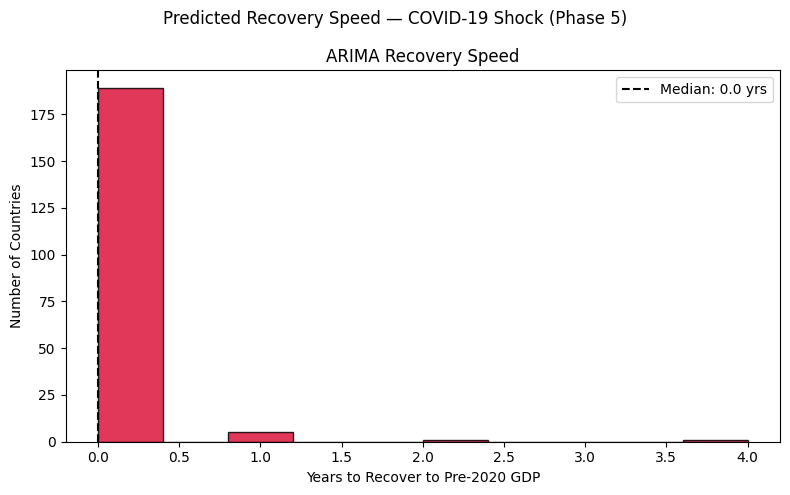

In [10]:
def compute_recovery_speed(pred_df, pred_col, pre_shock_year=2020):
    """Years for each country to recover to 2020 COVID shock GDP per model prediction.
    
    CORRECTED FORMULA:
    - Baseline = actual 2020 GDP (the COVID shock year)
    - Recovery year = first year >= 2020 where predicted_gdp >= baseline
    - This avoids negative recovery speeds from pre-2020 ARIMA predictions
    """
    records = []
    for country, grp in pred_df.groupby('country_code'):
        grp = grp.sort_values('year')
        pre_row = df[(df['country_code'] == country) & (df['year'] == pre_shock_year)]['gdp_per_capita']
        if pre_row.empty:
            continue
        pre_gdp = pre_row.values[0]
        # CORRECTED: Only consider years >= 2020 (ignore pre-2020 predictions)
        recovered = grp[(grp['year'] >= pre_shock_year) & (grp[pred_col] >= pre_gdp)]
        speed = int(recovered['year'].min()) - 2020 if not recovered.empty else np.nan
        records.append({'country_code': country, f'{pred_col}_recovery_years': speed})
    return pd.DataFrame(records)

arima_rec = compute_recovery_speed(arima_preds, 'arima_pred')

print('ARIMA Recovery speed (years after 2020 to regain pre-shock GDP):')
print(arima_rec['arima_pred_recovery_years'].describe())

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
data = arima_rec['arima_pred_recovery_years'].dropna()
if not data.empty:
    ax.hist(data, bins=10, color='crimson', edgecolor='black', alpha=0.85)
    ax.axvline(data.median(), color='black', ls='--', lw=1.5,
               label=f'Median: {data.median():.1f} yrs')
    ax.set_title('ARIMA Recovery Speed')
    ax.set_xlabel('Years to Recover to Pre-2020 GDP')
    ax.set_ylabel('Number of Countries')
    ax.legend()

plt.suptitle('Predicted Recovery Speed — COVID-19 Shock (Phase 5)', fontsize=12)
plt.tight_layout()
plt.savefig(r'..\output\phase5_recovery_speed.png', dpi=150)
plt.show()

## 9. Save Results

In [11]:
# ── Save ARIMA predictions (standardized format) ─────────────────────────────
arima_out = arima_preds[["country_code", "year", "actual", "arima_pred"]].copy()
arima_out.columns = ["country_code", "year", "actual", "predicted"]
arima_out.to_csv(os.path.join(OUTPUT, "arima_test_predictions.csv"), index=False)

# ── Recovery speed CSV ─────────────────────────────────────────────────────────
arima_rec.to_csv(os.path.join(OUTPUT, "phase5_arima_recovery_speed.csv"), index=False)

# ── Append ARIMA to model_metrics.csv ──────────────────────────────────────────
# Load what Phase 4 already wrote (Naive, HistMean, XGBoost)
existing_metrics = pd.read_csv(os.path.join(OUTPUT, "model_metrics.csv"), index_col=0)

new_rows = pd.DataFrame({
    "ARIMA":   {k: round(v, 4) for k, v in arima_metrics.items()},
}).T
new_rows.columns = existing_metrics.columns

# Only add rows that are not already present (idempotent)
to_add = new_rows[~new_rows.index.isin(existing_metrics.index)]
combined_metrics = pd.concat([existing_metrics, to_add])
combined_metrics.to_csv(os.path.join(OUTPUT, "model_metrics.csv"))

print("Files saved:")
print("  arima_test_predictions.csv")
print("  phase5_arima_recovery_speed.csv")
print("  model_metrics.csv (appended ARIMA)")
print()
print("=== model_metrics.csv (all models so far) ===")
print(combined_metrics.to_string())

Files saved:
  arima_test_predictions.csv
  phase5_arima_recovery_speed.csv
  model_metrics.csv (appended ARIMA)

=== model_metrics.csv (all models so far) ===
               MAE       RMSE    MAPE   MASE      DA
Naive    1259.1600  3651.3900  4.8074 1.0000  0.0000
HistMean 6348.0000 10167.3600 25.6551 5.0415 34.6375
XGBoost  1254.2252  3602.8139  4.8556 0.9961 59.2635
ARIMA    1945.0129  5883.8395  7.6090 1.5447 59.8094


---
## Phase 5 Complete

**Model used:**
- **ARIMA(1,1,1)** — per-country fit, AIC-minimised, d=1 first differencing

**Outputs saved:**
- `output/arima_test_predictions.csv` — 2020-2024 predictions for 212 countries
- `output/phase5_arima_recovery_speed.csv` — Recovery years per country
- `output/model_metrics.csv` (extended with ARIMA row)
- `output/phase5_model_comparison.png` — XGBoost vs ARIMA metrics
- `output/phase5_country_forecasts.png` — GDP trajectories (5 sample countries)
- `output/phase5_recovery_speed.png` — ARIMA recovery distribution

**Next → Phase 6:** LSTM Model (TensorFlow/Keras)